# 🧨 Diffusion Models with PyTorch
A Tiny U-Net Learns to Denoise MNIST

**Tarun Reddy Nukala (@ntreddy)**  
Presented at PyTorch ATX Meetup

This notebook demonstrates how a simple U-Net model can be used to denoise MNIST digits using a diffusion-like process. The model learns to reconstruct clean images from noisy inputs, simulating the reverse of a diffusion process.

### Packages, Imports, and Environment Setup

In [ ]:
# Install required packages
%pip install torch torchvision matplotlib numpy

In [ ]:
# Imports and environment setup
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

# Add the src directory to the Python path for imports
sys.path.append('../src')
from diffusion import q_sample, get_noise_schedule
from model import UNet

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


### Dataset Download & Preparation

In [ ]:
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(mnist, batch_size=64, shuffle=True)

print(f"✅ MNIST dataset loaded successfully!")
print(f"Dataset size: {len(mnist)} training samples")
print(f"Batch size: {dataloader.batch_size}")

### Model Training

In [4]:
# Train model to predict x₀ (clean image)
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

T = 100
betas = get_noise_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

epochs = 12
model.train()
for epoch in range(epochs):
    for batch_idx, (x, _) in enumerate(dataloader):
        x = x.to(device)
        uniform = torch.rand(x.size(0), device=device)
        log_timesteps = (uniform.log() / torch.tensor(T).log()).clamp(min=-1)
        t = (T * (1.0 + log_timesteps)).long().clamp(0, T - 1)
        noise = torch.randn_like(x)
        x_noisy = q_sample(x, t, noise, alphas_cumprod)
        pred_x0 = model(x_noisy)
        loss = criterion(pred_x0, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1} Batch {batch_idx} Loss: {loss.item():.4f}")

Epoch 1 Batch 0 Loss: 0.1504
Epoch 1 Batch 20 Loss: 0.0430
Epoch 1 Batch 40 Loss: 0.0443
Epoch 1 Batch 60 Loss: 0.0371
Epoch 1 Batch 80 Loss: 0.0353
Epoch 1 Batch 100 Loss: 0.0356
Epoch 1 Batch 120 Loss: 0.0355
Epoch 1 Batch 140 Loss: 0.0328
Epoch 1 Batch 160 Loss: 0.0299
Epoch 1 Batch 180 Loss: 0.0281
Epoch 1 Batch 200 Loss: 0.0306
Epoch 1 Batch 220 Loss: 0.0315
Epoch 1 Batch 240 Loss: 0.0283
Epoch 1 Batch 260 Loss: 0.0288
Epoch 1 Batch 280 Loss: 0.0286
Epoch 1 Batch 300 Loss: 0.0302
Epoch 1 Batch 320 Loss: 0.0293
Epoch 1 Batch 340 Loss: 0.0265
Epoch 1 Batch 360 Loss: 0.0279
Epoch 1 Batch 380 Loss: 0.0309
Epoch 1 Batch 400 Loss: 0.0273
Epoch 1 Batch 420 Loss: 0.0268
Epoch 1 Batch 440 Loss: 0.0266
Epoch 1 Batch 460 Loss: 0.0252
Epoch 1 Batch 480 Loss: 0.0251
Epoch 1 Batch 500 Loss: 0.0257
Epoch 1 Batch 520 Loss: 0.0299
Epoch 1 Batch 540 Loss: 0.0267
Epoch 1 Batch 560 Loss: 0.0240
Epoch 1 Batch 580 Loss: 0.0254
Epoch 1 Batch 600 Loss: 0.0227
Epoch 1 Batch 620 Loss: 0.0272
Epoch 1 Batch 

In [5]:
# Save the model
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/unet_denoiser.pth")
print("Model saved.")

Model saved.


In [6]:
# Load model for inference
model = UNet().to(device)
model.load_state_dict(torch.load("models/unet_denoiser.pth", map_location=device))
model.eval()

# Sanity check forward pass
x_sample, _ = mnist[1]
x_sample = x_sample.unsqueeze(0).to(device)
with torch.no_grad():
    x_out = model(x_sample)
print("Model output min/max:", x_out.min().item(), x_out.max().item())

Model output min/max: -0.02693144790828228 1.0674022436141968


### Visualize Denoising

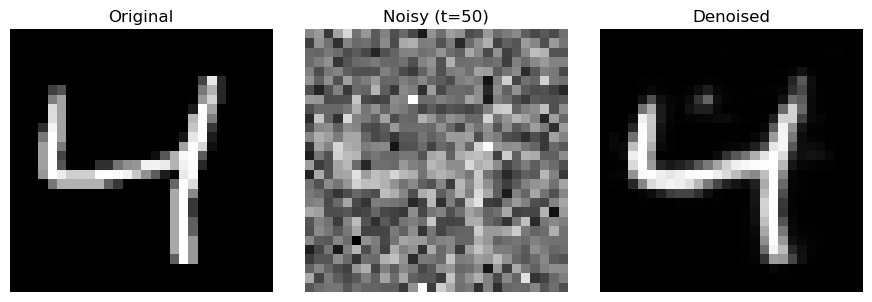

In [7]:
# Denoising function
def denoise_image(x_start, model, T=100, step=50):
    model.eval()
    x_start = x_start.to(device).unsqueeze(0)
    betas = get_noise_schedule(T).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    t = torch.tensor([step], device=device)
    noise = torch.randn_like(x_start)
    x_noisy = q_sample(x_start, t, noise, alphas_cumprod)
    with torch.no_grad():
        x_denoised = torch.clamp(model(x_noisy), 0.0, 1.0)
    imgs = [x_start.squeeze().cpu(), x_noisy.squeeze().cpu(), x_denoised.squeeze().cpu()]
    titles = ["Original", f"Noisy (t={step})", "Denoised"]
    fig, axs = plt.subplots(1, 3, figsize=(9, 3))
    for i in range(3):
        axs[i].imshow(imgs[i].numpy(), cmap="gray")
        axs[i].set_title(titles[i])
        axs[i].axis("off")
    plt.tight_layout()
    plt.show()

# Example usage
sample_img, _ = mnist[2]
denoise_image(sample_img, model, step=50)